In [64]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, LogisticRegression

In [65]:
AMOUNT_OF_POINTS = 50
SECOND_MEAN = 1.5
STANDARD_DEV = 0.5 ** 0.5

zero_class = np.random.normal(loc=0.5, scale=STANDARD_DEV, size=(AMOUNT_OF_POINTS, 1))
one_class = np.random.normal(loc=SECOND_MEAN, scale=STANDARD_DEV, size=(AMOUNT_OF_POINTS, 1))
data = np.block([
    [zero_class, np.zeros((AMOUNT_OF_POINTS, 1))],
    [one_class, np.ones((AMOUNT_OF_POINTS, 1))]
])
df = pd.DataFrame(data, columns=["x_1", "label"])
df.sample(10) # head, tail

,x_1,label
58,2.500447,1.0
3,2.304139,0.0
83,1.500232,1.0
60,1.601457,1.0
7,0.713758,0.0
88,1.295387,1.0
34,0.331444,0.0
21,-0.569081,0.0
71,0.548573,1.0
92,2.768840,1.0


In [66]:
linear = LinearRegression().fit(
    X=data[:, 0].reshape((-1, 1)),
    y=data[:, 1].reshape((-1, 1)),
)
y_lin = linear.coef_ * data[:, 0] + linear.intercept_

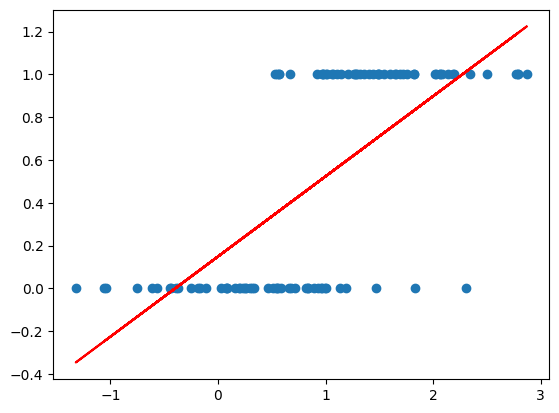

In [67]:
plt.plot(data[:, 0], y_lin.reshape((-1)), 'r')
plt.scatter(data[:, 0], data[:, 1])

In [68]:
def expit(X):
    return 1 / (1 + np.exp(-X))

logistic = LogisticRegression().fit(
    X=data[:, 0].reshape((-1, 1)),
    y=data[:, 1].reshape((-1, 1)),
)
X_test = np.linspace(0, 3, 300)
y_log = expit(X_test * logistic.coef_ + logistic.intercept_)

/home/lbiedma/miniconda3/envs/datascience/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


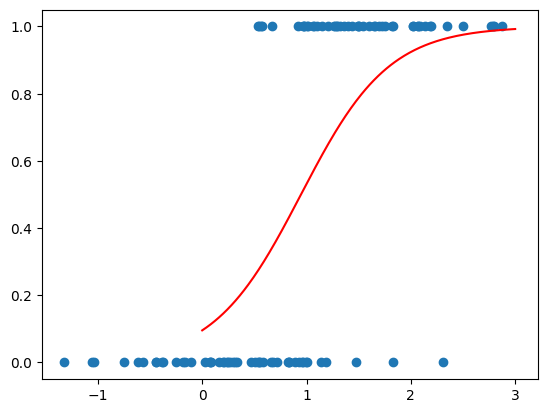

In [69]:
plt.plot(X_test, y_log.ravel(), 'r')
plt.scatter(data[:, 0], data[:, 1])